/opt/anaconda3/envs/ml-trading-platform/lib/python3.9/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-02-26 17:31:14.735462: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3 Pro
2025-02-26 17:31:14.735479: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 18.00 GB
2025-02-26 17:31:14.735483: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 6.00 GB
2025-02-26 17:31:14.735497: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-02-26 17:31:14.735506: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory

          Date  Step  Action  Reward  Cumulative_Reward  Realized_Profit  \
0   2023-05-10     1       0       0                  0              0.0   
1   2023-05-11     2       0       0                  0              0.0   
2   2023-05-12     3       0       0                  0              0.0   
3   2023-05-15     4       0       0                  0              0.0   
4   2023-05-16     5       0       0                  0              0.0   
5   2023-05-17     6       0       0                  0              0.0   
6   2023-05-18     7       0       0                  0              0.0   
7   2023-05-19     8       0       0                  0              0.0   
8   2023-05-22     9       0       0                  0              0.0   
9   2023-05-23    10       0       0                  0              0.0   
10  2023-05-24    11       0       0                  0              0.0   
11  2023-05-25    12       0       0                  0              0.0   
12  2023-05-

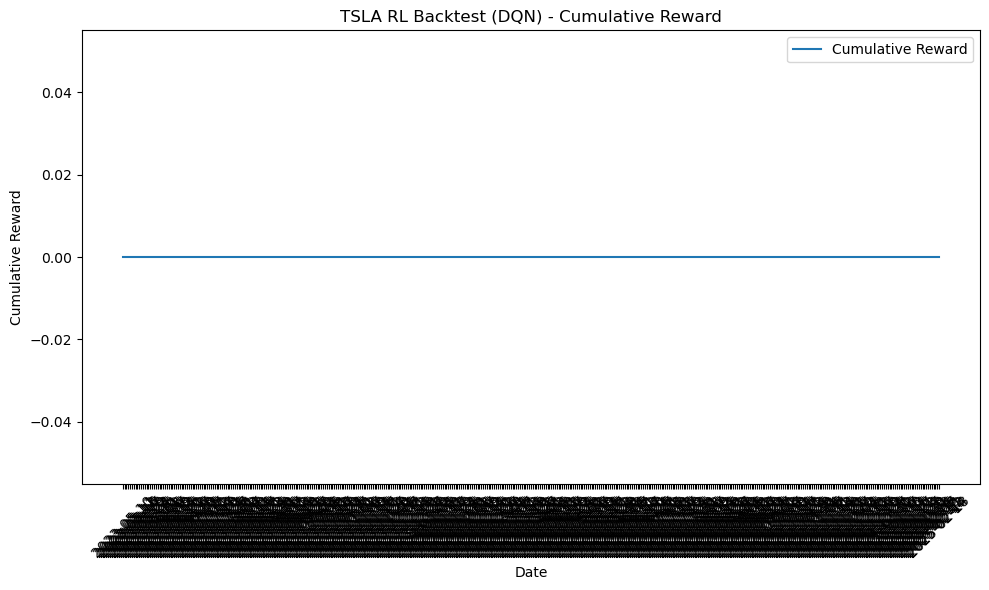

REALIZED PROFIT: 
0.0


In [1]:
# main.py
import sys
import os

# Get the absolute path to the `src` directory
src_path = os.path.abspath(os.path.join('../..', 'src'))

# Add the `src` directory to the Python path
if src_path not in sys.path:
    sys.path.append(src_path)

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
from dqn_agent import DQNAgent
from trading_env import StockTradingEnv


df_backtest = pd.read_csv("TSLA_RL_backtest_input.csv")

# Ensure columns match environment's expectations:
#   e.g. ["Date", "Open", "High", "Low", "Close", "Volume", "XGB_Pred", "XGB_Prob_Up"]
# If you have more columns, drop or rename as needed. 
# If 'Date' is present, it's fine if the environment doesn't explicitly use it.

# 4. Create the environment for backtesting
env_test = StockTradingEnv(df_backtest)

# 5. Create a DQNAgent with the same state_size & action_size as used in training
agent_test = DQNAgent(state_size=env_test.state_size, action_size=len(env_test.action_space))

def custom_mse(y_true, y_pred):
    return tf.reduce_mean(tf.square(y_pred - y_true))

custom_objects = {
    "mse": custom_mse
}

model = tf.keras.models.load_model(
    "tsla_dqn.h5", 
    custom_objects=custom_objects
)

# 7. Run the backtest
def backtest_agent(agent, env):
    state = env.reset()
    done = False
    logs = []
    cumulative_reward = 0

    while not done:
        action = agent.act(state)  # or pass an epsilon if your agent supports it
        next_state, reward, done, info = env.step(action)
        cumulative_reward += reward

        date_val = None
        if env.current_step < len(env.df):
            date_val = env.df.iloc[env.current_step]["Date"]
        
        # info contains "realized_profit" each step
        logs.append({
            "Date": date_val,
            "Step": env.current_step,
            "Action": action,
            "Reward": reward,
            "Cumulative_Reward": cumulative_reward,
            "Realized_Profit": info["realized_profit"],
            "Balance": info["balance"],
            "Close": env.df.iloc[env.current_step - 1]["Close"] if env.current_step > 0 else None
        })
        
        state = next_state

    return pd.DataFrame(logs)

df_results = backtest_agent(agent_test, env_test)

# 8. Inspect the results
print(df_results.head(15))

# 9. (Optional) Plot cumulative reward
plt.figure(figsize=(10,6))
plt.plot(df_results["Date"], df_results["Cumulative_Reward"], label="Cumulative Reward")
plt.xticks(rotation=45)
plt.xlabel("Date")
plt.ylabel("Cumulative Reward")
plt.title("TSLA RL Backtest (DQN) - Cumulative Reward")
plt.legend()
plt.tight_layout()
plt.show()

print("REALIZED PROFIT: ")
print(df_results["Realized_Profit"].iloc[-1])